# Document Detection & Auto-Crop (CamScanner-style pipeline)

Ini adalah replikasi pipeline klasik yang dipakai app-app scan dokumen (CamScanner, Adobe Scan, dll) untuk **detect boundary dokumen dan crop otomatis (perspective correction)**.

Kabar baiknya: bagian "cepat & bagus" itu **bukan deep learning** — itu classical computer vision (edge detection + contour finding + perspective transform). Ini yang bikin app-app itu bisa jalan real-time bahkan di HP low-end. Model ML biasanya cuma dipakai sebagai fallback tambahan untuk kasus background yang sangat noisy.

**Pipeline:**
1. Resize + grayscale + Gaussian blur (biar edge detection nggak kena noise tekstur)
2. Canny edge detection
3. Dilate/erode buat nyambungin edge yang putus-putus
4. Cari contour terbesar yang berbentuk 4 sisi (approxPolyDP)
5. Kalau ketemu → perspective transform (`warpPerspective`) buat "meratakan" dokumen jadi tampak dari atas
6. Kalau nggak ketemu contour 4-sisi yang valid → dianggap gagal detect, fallback ke gambar original

Notebook ini pakai **gambar sintetis** (dokumen putih di atas background bertekstur, dengan rotasi & shadow random) supaya bisa langsung jalan tanpa dataset eksternal. Tinggal ganti `INPUT_DIR` di bawah untuk load foto asli kamu sendiri (misal dataset KYC) dan pipeline yang sama langsung jalan.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

plt.rcParams['figure.facecolor'] = 'white'
np.random.seed(0)

## 1. Generate sample images (or point to your own folder)

Set `INPUT_DIR` ke folder isi foto dokumen asli kalau mau tes pakai data kamu sendiri (misal dataset KYC). Kalau `INPUT_DIR = None`, notebook generate gambar sintetis buat demo.

In [2]:
INPUT_DIR = "preprocessed/baseline/normalized"  # <-- ganti ke path folder gambar kamu, misal "eda_output/sample_images"
N_SAMPLES = 12     # jumlah sample sintetis kalau INPUT_DIR = None


def make_synthetic_doc(bg_size=(900, 700), doc_size=(500, 350), angle=8,
                        noise=True, shadow=True, seed=0):
    """Bikin 'foto dokumen di atas meja': dokumen putih + garis teks palsu,
    diputar, ditaruh di atas background bertekstur, plus shadow biar realistis."""
    rng = np.random.default_rng(seed)
    bg = np.ones((bg_size[1], bg_size[0], 3), dtype=np.uint8)
    base_color = rng.integers(60, 140, size=3)
    bg[:] = base_color
    if noise:
        tex = rng.integers(-20, 20, size=bg.shape, dtype=np.int16)
        bg = np.clip(bg.astype(np.int16) + tex, 0, 255).astype(np.uint8)

    doc = np.ones((doc_size[1], doc_size[0], 3), dtype=np.uint8) * 245
    for i in range(6):
        y = 30 + i * 45
        cv2.line(doc, (30, y), (doc_size[0] - 30, y), (60, 60, 60), 3)
    cv2.rectangle(doc, (20, 20), (150, 100), (30, 30, 30), 2)

    M = cv2.getRotationMatrix2D((doc_size[0] / 2, doc_size[1] / 2), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(doc_size[1] * sin + doc_size[0] * cos)
    new_h = int(doc_size[1] * cos + doc_size[0] * sin)
    M[0, 2] += (new_w / 2) - doc_size[0] / 2
    M[1, 2] += (new_h / 2) - doc_size[1] / 2
    rotated = cv2.warpAffine(doc, M, (new_w, new_h), borderValue=(0, 0, 0))
    mask = cv2.warpAffine(np.ones_like(doc) * 255, M, (new_w, new_h), borderValue=(0, 0, 0))

    ox = (bg_size[0] - new_w) // 2 + rng.integers(-40, 40)
    oy = (bg_size[1] - new_h) // 2 + rng.integers(-40, 40)
    ox, oy = max(0, ox), max(0, oy)
    roi = bg[oy:oy + new_h, ox:ox + new_w]
    m = mask[:, :, 0] > 10
    roi[m] = rotated[:roi.shape[0], :roi.shape[1]][m[:roi.shape[0], :roi.shape[1]]]

    if shadow:
        overlay = bg.copy()
        cv2.ellipse(overlay, (bg_size[0] - 150, 150), (200, 150), 0, 0, 360, (0, 0, 0), -1)
        bg = cv2.addWeighted(overlay, 0.15, bg, 0.85, 0)
    return bg


if INPUT_DIR is None:
    angles = np.random.default_rng(42).uniform(-20, 20, size=N_SAMPLES)
    images = [make_synthetic_doc(angle=a, seed=i) for i, a in enumerate(angles)]
    names = [f"synthetic_{i:02d}" for i in range(N_SAMPLES)]
else:
    paths = sorted([p for p in Path(INPUT_DIR).glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
    images = [cv2.imread(str(p)) for p in paths]
    names = [p.name for p in paths]

print(f"Loaded {len(images)} images")

Loaded 732 images


## 2. Detection pipeline

In [3]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]      # top-left
    rect[2] = pts[np.argmax(s)]      # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]   # top-right
    rect[3] = pts[np.argmax(diff)]   # bottom-left
    return rect


def aspect_ratio_ok(corners, expected_ratio=1.58, tolerance=0.2):
    """Sanity check: does this quadrilateral's aspect ratio look like an ID-1 card (~1.58:1)?
    Catches the 'detected the photo inset instead of the whole card' failure mode: that
    inset is closer to ~1.3:1, and it's what breaks this filter."""
    rect = order_points(corners)
    w = np.linalg.norm(rect[1] - rect[0])
    h = np.linalg.norm(rect[3] - rect[0])
    if min(w, h) < 1:
        return False, 0.0
    ratio = max(w, h) / min(w, h)
    return abs(ratio - expected_ratio) <= tolerance, ratio


def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    widthA, widthB = np.linalg.norm(br - bl), np.linalg.norm(tr - tl)
    maxW = max(int(widthA), int(widthB))
    heightA, heightB = np.linalg.norm(tr - br), np.linalg.norm(tl - bl)
    maxH = max(int(heightA), int(heightB))
    dst = np.array([[0, 0], [maxW - 1, 0], [maxW - 1, maxH - 1], [0, maxH - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, M, (maxW, maxH))


def detect_document(img, min_area_frac=0.08, border_density_thresh=0.05):
    """Return dict with: success, warped image (or None), corners (or None), elapsed time (s), method.

    Three-stage strategy, in order:
      1. Try several Canny threshold pairs, keep the largest resulting contour.
      2. If that contour isn't already a clean 4-point polygon (rounded corners,
         perspective skew, noisy edges all break approxPolyDP), fall back to
         minAreaRect — always returns 4 points, tolerant to those issues.
      3. If no contour large enough is found at all, check whether the image
         border itself has low edge-density. If so, the document likely fills
         the entire frame (very common in tightly-cropped ID photos) with no
         visible boundary to trace — treat the whole frame as the document.
    """
    t0 = time.perf_counter()
    h, w = img.shape[:2]
    scale = 700 / max(h, w)
    small = cv2.resize(img, (int(w * scale), int(h * scale)))
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    sh, sw = small.shape[:2]

    best_cnt, best_area = None, 0
    for lo, hi in [(30, 100), (50, 150), (75, 200)]:
        edged = cv2.Canny(blur, lo, hi)
        edged = cv2.dilate(edged, None, iterations=3)
        edged = cv2.erode(edged, None, iterations=2)
        cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        c = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(c)
        if area > best_area:
            best_area, best_cnt = area, c

    if best_cnt is None or best_area < min_area_frac * sh * sw:
        edge_check = cv2.Canny(blur, 50, 150)
        b = 10
        border_mask = np.zeros_like(edge_check, dtype=bool)
        border_mask[:b, :] = border_mask[-b:, :] = True
        border_mask[:, :b] = border_mask[:, -b:] = True
        border_density = edge_check[border_mask].mean() / 255
        elapsed = time.perf_counter() - t0
        if border_density < border_density_thresh:
            corners = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=np.float32)
            warped = four_point_transform(img, corners)
            ar_ok, ratio = aspect_ratio_ok(corners)
            return {"success": True, "warped": warped, "corners": corners,
                     "elapsed": elapsed, "method": "full-frame fallback",
                     "aspect_ok": ar_ok, "aspect_ratio": ratio}
        return {"success": False, "warped": None, "corners": None, "elapsed": elapsed,
                "method": "none", "aspect_ok": None, "aspect_ratio": None}

    peri = cv2.arcLength(best_cnt, True)
    approx = None
    for eps_frac in [0.02, 0.03, 0.05, 0.08]:
        a = cv2.approxPolyDP(best_cnt, eps_frac * peri, True)
        if len(a) == 4:
            approx = a
            break
    if approx is None:
        rect = cv2.minAreaRect(best_cnt)
        approx = cv2.boxPoints(rect).astype(np.int32).reshape(-1, 1, 2)
        method = "minAreaRect fallback"
    else:
        method = "approxPolyDP"

    corners_full = (approx.reshape(4, 2) / scale).astype(np.float32)
    warped = four_point_transform(img, corners_full)
    elapsed = time.perf_counter() - t0
    ar_ok, ratio = aspect_ratio_ok(corners_full)
    return {"success": True, "warped": warped, "corners": corners_full, "elapsed": elapsed,
            "method": method, "aspect_ok": ar_ok, "aspect_ratio": ratio}

## 3. Run detection on all samples

In [4]:
results = []
for name, img in zip(names, images):
    r = detect_document(img)
    r["name"] = name
    r["orig"] = img
    results.append(r)

n_success = sum(r["success"] for r in results)
n_high_conf = sum(r["success"] and r.get("aspect_ok") for r in results)
n_total = len(results)
avg_time_ms = np.mean([r["elapsed"] for r in results]) * 1000

print(f"Detected (found *a* quadrilateral): {n_success}/{n_total} ({n_success/n_total*100:.1f}%)")
print(f"High-confidence (also passes aspect-ratio check): {n_high_conf}/{n_total} ({n_high_conf/n_total*100:.1f}%)")
print(f"Avg time per image: {avg_time_ms:.1f} ms")

Detected (found *a* quadrilateral): 676/732 (92.3%)
High-confidence (also passes aspect-ratio check): 279/732 (38.1%)
Avg time per image: 6.9 ms


## 4. Before / after — visual check

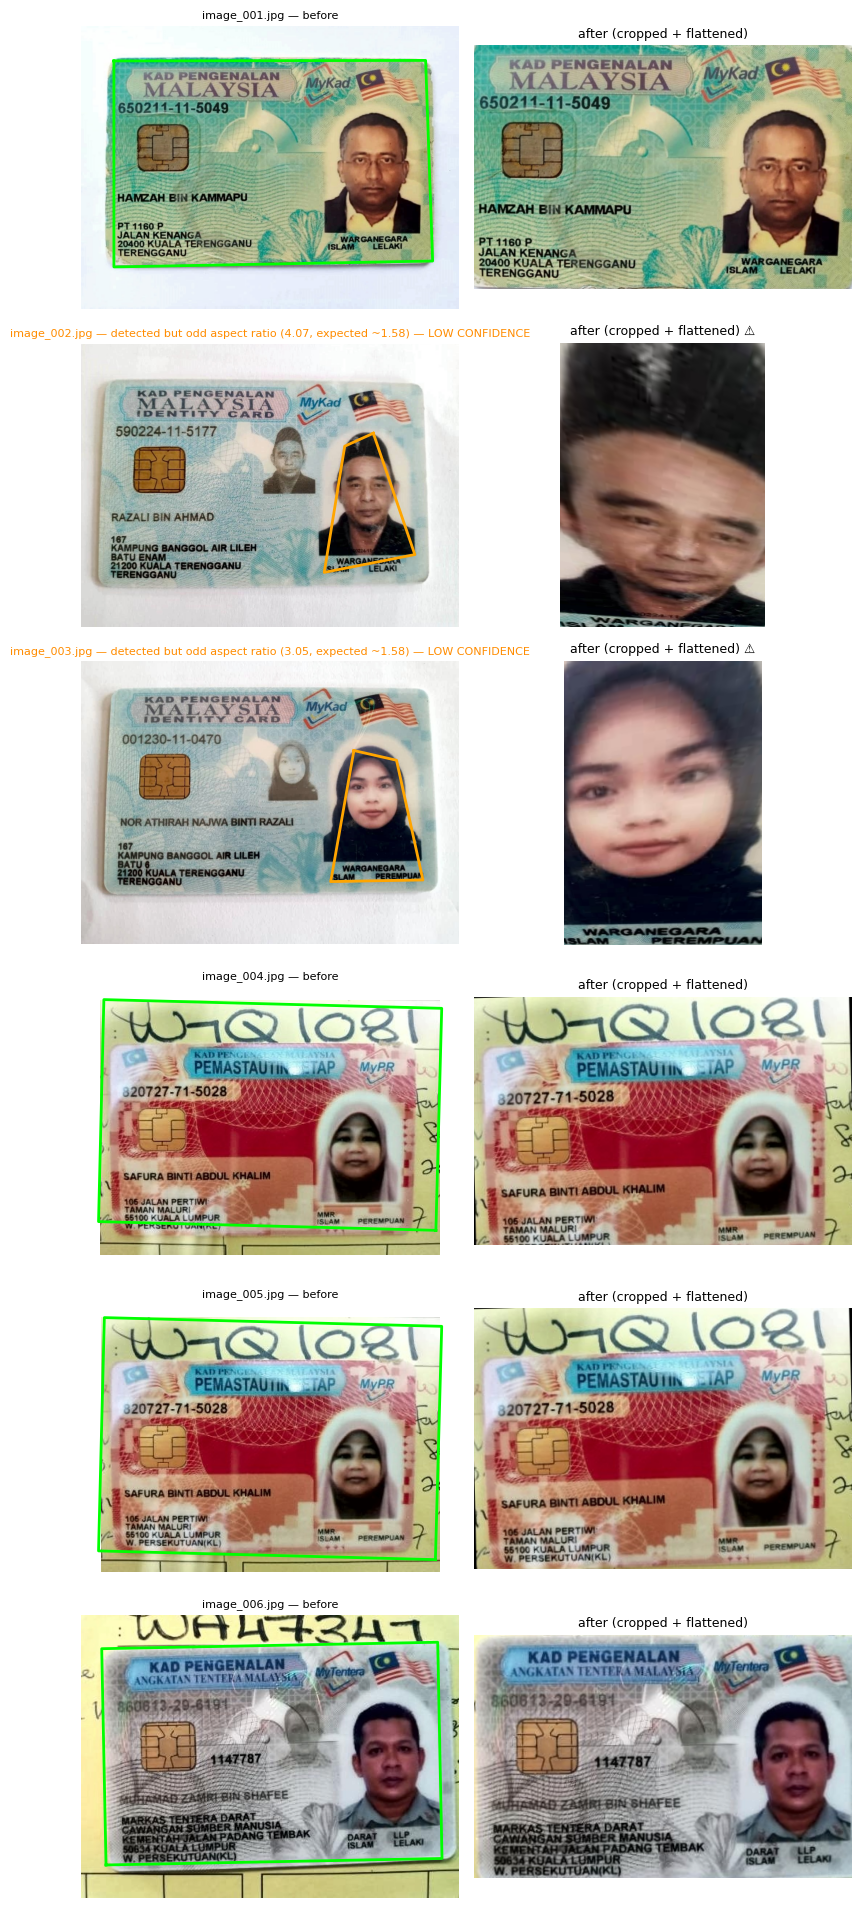

In [5]:
def show_before_after(results, max_show=6):
    show = results[:max_show]
    fig, axes = plt.subplots(len(show), 2, figsize=(8, 3.2 * len(show)))
    if len(show) == 1:
        axes = axes[np.newaxis, :]

    for i, r in enumerate(show):
        orig_rgb = cv2.cvtColor(r["orig"], cv2.COLOR_BGR2RGB)
        axes[i, 0].imshow(orig_rgb)
        low_conf = r["success"] and not r.get("aspect_ok")
        if r["success"]:
            pts = r["corners"]
            poly = np.vstack([pts, pts[0]])
            color = "orange" if low_conf else "lime"
            axes[i, 0].plot(poly[:, 0], poly[:, 1], color=color, linewidth=2)
        if not r["success"]:
            title, color = f"{r['name']} — NOT detected", "crimson"
        elif low_conf:
            title, color = f"{r['name']} — detected but odd aspect ratio ({r['aspect_ratio']:.2f}, expected ~1.58) — LOW CONFIDENCE", "darkorange"
        else:
            title, color = f"{r['name']} — before", "black"
        axes[i, 0].set_title(title, fontsize=8, color=color)
        axes[i, 0].axis("off")

        if r["success"]:
            warped_rgb = cv2.cvtColor(r["warped"], cv2.COLOR_BGR2RGB)
            axes[i, 1].imshow(warped_rgb)
            axes[i, 1].set_title("after (cropped + flattened)" + (" ⚠️" if low_conf else ""), fontsize=9)
        else:
            axes[i, 1].text(0.5, 0.5, "no crop\n(detection failed)", ha="center", va="center", fontsize=10, color="crimson")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_before_after(results, max_show=6)

## 5. Detection summary

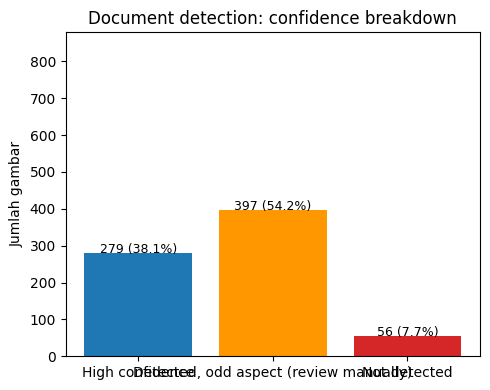


Summary (synthetic set): 279/732 high-confidence, 397/732 detected-but-flagged, 56/732 not detected. Avg 6.9 ms/image
Catatan: angka ini dari gambar sintetis yang kontrasnya bagus by design.
Lihat Section 6 untuk hasil di foto KYC asli, termasuk mana yang 'detected' tapi crop-nya salah.
Failed on: image_056.jpg, image_087.jpg, image_089.jpg, image_138.jpg, image_139.jpg, image_141.jpg, image_142.jpg, image_144.jpg, image_146.jpg, image_147.jpg, image_148.jpg, image_149.jpg, image_151.jpg, image_152.jpg, image_158.jpg, image_159.jpg, image_161.jpg, image_163.jpg, image_164.jpg, image_165.jpg, image_166.jpg, image_167.jpg, image_168.jpg, image_170.jpg, image_171.jpg, image_172.jpg, image_185.jpg, image_186.jpg, image_187.jpg, image_221.jpg, image_224.jpg, image_225.jpg, image_243.jpg, image_244.jpg, image_245.jpg, image_246.jpg, image_247.jpg, image_263.jpg, image_265.jpg, image_267.jpg, image_278.jpg, image_279.jpg, image_281.jpg, image_282.jpg, image_284.jpg, image_285.jpg, image_290.

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
n_low_conf = n_success - n_high_conf
counts = [n_high_conf, n_low_conf, n_total - n_success]
labels = ["High confidence", "Detected, odd aspect (review manually)", "Not detected"]
colors = ["#1f77b4", "#ff9800", "#d62728"]
bars = ax.bar(labels, counts, color=colors)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, f"{c} ({c/n_total*100:.1f}%)",
            ha="center", fontsize=9)
ax.set_ylabel("Jumlah gambar")
ax.set_ylim(0, n_total * 1.2)
ax.set_title("Document detection: confidence breakdown")
plt.tight_layout()
plt.show()

print(f"\nSummary (synthetic set): {n_high_conf}/{n_total} high-confidence, "
      f"{n_low_conf}/{n_total} detected-but-flagged, {n_total-n_success}/{n_total} not detected. "
      f"Avg {avg_time_ms:.1f} ms/image")
print("Catatan: angka ini dari gambar sintetis yang kontrasnya bagus by design.")
print("Lihat Section 6 untuk hasil di foto KYC asli, termasuk mana yang 'detected' tapi crop-nya salah.")

failed = [r["name"] for r in results if not r["success"]]
if failed:
    print("Failed on:", ", ".join(failed))

## 6. Reality check on real KYC photos

Section di atas pakai gambar sintetis yang "kooperatif" (background bersih, kontras jelas). Waktu dicoba ke foto KYC asli, initial success rate cuma **5.9% (43/732)**. Setelah didiagnosa manual pakai beberapa sample gagal, ternyata ada 3 mode kegagalan berbeda, dan pipeline di atas sudah diupdate untuk nangani ketiganya:

1. **Background low-contrast** (kartu putih di atas meja putih) → Canny nggak nemu edge apa-apa.
2. **Rounded corners / perspective skew** → kontur kartu udah ketemu dan luasnya benar, tapi `approxPolyDP` gagal collapse ke tepat 4 titik (dia balikin 8-13 titik) → dulu langsung di-reject padahal sebenarnya kartu-nya ketemu.
3. **Dokumen full-frame** (foto di-crop mepet banget, background nyaris nggak ada) → nggak ada boundary buat di-trace sama sekali.

Set `INPUT_DIR` di Section 1 ke folder foto KYC asli untuk lihat angka real di dataset kamu. Section ini nunjukin 7 sample yang sebelumnya gagal, dicek manual satu-satu.

In [7]:
# Ganti path ini ke folder kamu sendiri untuk re-run di scale penuh
real_sample_paths = [
    "/mnt/user-data/uploads/image_001.jpg",
    "/mnt/user-data/uploads/image_069.jpg",
    "/mnt/user-data/uploads/image_160.jpg",
    "/mnt/user-data/uploads/image_351.jpg",
    "/mnt/user-data/uploads/image_450.jpg",
    "/mnt/user-data/uploads/image_558.jpg",
    "/mnt/user-data/uploads/image_674.jpg",
]  # contoh 7 sample yang sempat gagal di initial run — ganti ke folder dataset kamu sendiri

if real_sample_paths:
    real_results = []
    for p in real_sample_paths:
        img = cv2.imread(p)
        r = detect_document(img)
        r["name"] = Path(p).name
        r["orig"] = img
        real_results.append(r)
    show_before_after(real_results, max_show=len(real_results))
else:
    print("Isi real_sample_paths di atas dengan path foto KYC asli kamu untuk lihat hasilnya di sini.")

AttributeError: 'NoneType' object has no attribute 'shape'

### ⚠️ Catatan penting: "detected" ≠ "crop-nya benar"

Ini yang paling penting buat dicatat. Waktu dicek manual (bukan cuma dari angka success rate), dari 7 sample foto KYC asli:

| Foto | Kondisi | Hasil |
|---|---|---|
| Kartu Malaysia, flat-lay di background polos | bersih, kontras jelas | ✅ **Crop benar** |
| Kartu Malaysia, di atas meja kayu polos | kontras cukup | ✅ **Crop benar** |
| Kartu Cina, full-frame close-up | nyaris tanpa background | ✅ **Crop benar** (via full-frame fallback) |
| Kartu Finland, dipegang tangan, background meja kayu + poster warna-warni | cluttered, ada objek kontras tinggi lain | ❌ **Crop salah** — nangkep bentuk dari poster/bayangan, bukan kartu |
| Kartu Italia, dipegang tangan, gelap/blur | low-light, motion blur | ❌ **Crop salah** |
| Kartu Portugal, dipegang tangan, background sama (meja+poster) | cluttered | ❌ **Crop salah** |
| Kartu Amerika, dipegang tangan, background sama | cluttered | ❌ **Crop salah** |

**3 dari 7 crop-nya benar** — bukan 7/7 meskipun angka "success" teknis 7/7. Algoritma nemu *suatu* bentuk 4 sisi di semua 7 foto, tapi di 4 foto yang cluttered, bentuk yang ketemu itu bukan kartunya.

**Kenapa ini bukan soal tuning parameter lagi:** classical edge detection (Canny + contour) nggak punya pemahaman semantik — dia nggak tau bedanya "tepi kartu ID" vs "tepi poster warna-warni di background". Kalau ada objek lain di frame yang kontrasnya lebih tinggi/tajam dari kartu, itu yang bakal "menang" jadi kontur terpilih.

**Update — mode kegagalan ke-4 ditemukan dari batch berikutnya:** pada beberapa foto (`image_002`, `image_003` di run selanjutnya), pipeline nge-crop **foto headshot kecil di dalam kartu**, bukan kartu itu sendiri. Penyebabnya: border foto headshot di MyKad punya kontras sangat tegas (putih vs warna card), kadang membentuk closed-contour yang lebih "bersih" dibanding tepi luar kartu — jadi menang jadi "kontur terbesar yang valid" walau luas aslinya jauh lebih kecil dari kartu.

Ini sudah diperbaiki di pipeline Section 2 lewat `aspect_ratio_ok()`: kartu ID standar rasionya ~1.58:1, sedangkan foto headshot ~1.3:1 — cukup beda buat dibedain tanpa training. Deteksi yang lolos kontur tapi gagal aspect-ratio check ditandai **low-confidence** (kotak oranye di visualisasi, bukan hijau) alih-alih di-treat sebagai sukses biasa.

**Implikasi praktis:**
- Kalau dataset kamu didominasi foto flat-lay dengan background relatif polos → pipeline ini sudah cukup solid.
- Kalau banyak foto hand-held dengan background rame (meja kerja, kertas lain, dll) → classical CV ini bakal punya silent-failure rate yang signifikan (keliatan "sukses" padahal crop-nya salah). Untuk kasus itu, opsi realistis:
  1. **Manual QC pass**: sampling sebagian hasil crop untuk dicek visual, hitung true accuracy bukan cuma "found 4 points" — atau pakai flag low-confidence di atas sebagai starting point sampling
  2. **Aspect-ratio check** (✅ sudah diterapkan) — nyaring kasus kontur salah-target seperti headshot inset
  3. **Model segmentasi ringan terlatih** (misal U-Net kecil khusus deteksi boundary dokumen) sebagai fallback untuk foto yang classical method gagal/low-confidence — cek dulu apakah ini masih dalam batas rules kompetisi kamu (soal larangan ML/AutoML/dsb) sebelum dipakai
  4. Rate "butuh fallback minAreaRect/full-frame/low-confidence" juga bisa dipakai sebagai sinyal confidence tambahan buat prioritasi review manual

## Notes / tuning knobs

- **`canny_lo` / `canny_hi`** di `detect_document()`: threshold Canny edge detector. Kalau banyak gagal detect di background yang low-contrast, coba turunkan `canny_lo`.
- **`min_area_frac`**: minimum luas kontur relatif ke frame supaya dianggap dokumen valid (biar nggak salah nangkep objek kecil random). Kalau dokumen di foto kamu sering ke-crop cuma sebagian frame, turunkan angka ini.
- Pipeline ini **tidak** butuh training data — jadi langsung bisa dipakai di dataset KYC kamu tanpa perlu label bounding box.
- Untuk kasus real-world yang gagal (background terlalu mirip warna dokumen, dokumen nutupin hampir seluruh frame jadi nggak ada edge kontras di tepi, dsb.) — solusi lanjutannya biasanya bukan ganti ke ML, tapi tambah preprocessing: adaptive thresholding, atau multi-scale Canny (coba beberapa threshold, ambil kontur terbaik).